In [ ]:
# 폰트 설치
# 새 노트북 열 때마다 셀을 실행하고 세션 다시 시작

!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!pip install lightgbm -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

# Feature Engineering이 완료된 데이터
train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')
test_df  = pd.read_csv(DATA_DIR + 'test_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
로드 완료
train shape: (204000, 35)


In [ ]:
# 모든 실험에서 공통으로 사용할 feature, target, SMAPE 정의

FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
]
TRAIN_FEATURES = FEATURES + ['일조(hr)', '일사(MJ/m2)']
TARGET = '전력소비량(kWh)'

# SMAPE 정의
# 예측값과 실제값의 대칭 평균 절대 퍼센트 오차
# 값이 낮을수록 좋음
def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

# 검증 데이터 분리
# 마지막 7일을 검증용으로 사용
# 8/18 이전: 학습, 8/18 이후: 검증
train_mask = train_df['일시'] < '20240818 00'
val_mask   = train_df['일시'] >= '20240818 00'

train_x = train_df[TRAIN_FEATURES][train_mask]
train_y = train_df[TARGET][train_mask]
val_x   = train_df[TRAIN_FEATURES][val_mask]
val_y   = train_df[TARGET][val_mask]

print(f'학습 데이터: {len(train_x):,}행')
print(f'검증 데이터: {len(val_x):,}행')

# 실험 결과 기록용
results = {}

학습 데이터: 187,200행
검증 데이터: 16,800행


In [ ]:
from xgboost import XGBRegressor

# Baseline과 동일한 조건으로 재현
# FE 추가 전후 성능을 공정하게 비교하기 위한 기준점
model_exp1 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)
model_exp1.fit(
    train_x, train_y,
    eval_set=[(val_x, val_y)],
    verbose=False
)

pred_exp1 = model_exp1.predict(val_x)
score_exp1 = smape(val_y, pred_exp1)
results['실험1_Baseline_XGBoost'] = score_exp1

print(f'실험 1 Validation SMAPE: {score_exp1:.4f}')
print(f'(대회 Baseline 원본: 24.0140)')

실험 1 Validation SMAPE: 8.4242
(대회 Baseline 원본: 24.0140)


In [ ]:
from lightgbm import LGBMRegressor

# LightGBM을 선택한 이유:
# XGBoost보다 학습 속도가 빠르고
# 범주형 변수 처리와 결측치에 더 강건함
# 정형 데이터 대회에서 자주 상위권을 차지하는 모델
model_exp2 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
model_exp2.fit(
    train_x, train_y,
    eval_set=[(val_x, val_y)],
    callbacks=[
        __import__('lightgbm').early_stopping(50, verbose=False),
        __import__('lightgbm').log_evaluation(period=-1)
    ]
)

pred_exp2 = model_exp2.predict(val_x)
score_exp2 = smape(val_y, pred_exp2)
results['실험2_LightGBM'] = score_exp2

print(f'실험 2 Validation SMAPE: {score_exp2:.4f}')
print(f'실험 1 대비 개선: {score_exp1 - score_exp2:.4f}')

실험 2 Validation SMAPE: 9.3881
실험 1 대비 개선: -0.9639


In [ ]:
# 유형마다 시간대 패턴이 다르고 주말 영향 방향도 유형마다 반대
# 하나의 모델로 모든 유형을 학습하면 상충 발생
# 유형별로 개별 모델을 학습해서 각 패턴을 따로 반영

building_types = train_df['건물유형'].unique()
models_exp3    = {}
preds_exp3     = np.zeros(len(train_df))

for btype in building_types:
    train_mask = (train_df['일시'] < '20240818 00') & (train_df['건물유형'] == btype)
    val_mask   = (train_df['일시'] >= '20240818 00') & (train_df['건물유형'] == btype)

    tx = train_df[TRAIN_FEATURES][train_mask]
    ty = train_df[TARGET][train_mask]
    vx = train_df[TRAIN_FEATURES][val_mask]
    vy = train_df[TARGET][val_mask]

    if len(tx) == 0 or len(vx) == 0:
        print(f'  {btype} → 데이터 없음, 건너뜀')
        continue

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae'
    )
    model.fit(
        tx, ty,
        eval_set=[(vx, vy)],
        verbose=False
    )

    models_exp3[btype] = model
    preds_exp3[val_mask.values] = model.predict(vx)
    print(f'  {btype} 학습 완료 (학습 {len(tx):,}행, 검증 {len(vx):,}행)')

val_mask_all = train_df['일시'] >= '20240818 00'
score_exp3 = smape(train_df[TARGET][val_mask_all], preds_exp3[val_mask_all.values])
results['실험3_유형별_XGBoost'] = score_exp3

print(f'\n실험 3 Validation SMAPE: {score_exp3:.4f}')
print(f'실험 1 대비 개선: {score_exp1 - score_exp3:.4f}')

  호텔 학습 완료 (학습 18,720행, 검증 1,680행)
  상용 학습 완료 (학습 18,720행, 검증 1,680행)
  병원 학습 완료 (학습 16,848행, 검증 1,512행)
  학교 학습 완료 (학습 18,720행, 검증 1,680행)
  건물기타 학습 완료 (학습 18,720행, 검증 1,680행)
  아파트 학습 완료 (학습 16,848행, 검증 1,512행)
  연구소 학습 완료 (학습 16,848행, 검증 1,512행)
  백화점 학습 완료 (학습 29,952행, 검증 2,688행)
  IDC(전화국) 학습 완료 (학습 16,848행, 검증 1,512행)
  공공 학습 완료 (학습 14,976행, 검증 1,344행)

실험 3 Validation SMAPE: 7.2579
실험 1 대비 개선: 1.1663


실험 결과 비교
실험                                SMAPE      개선폭
--------------------------------------------------
대회 Baseline (원본)                24.0140        -
실험1_Baseline_XGBoost             8.4242 +15.5898
실험2_LightGBM                     9.3881  -0.9639
실험3_유형별_XGBoost                  7.2579  +2.1302


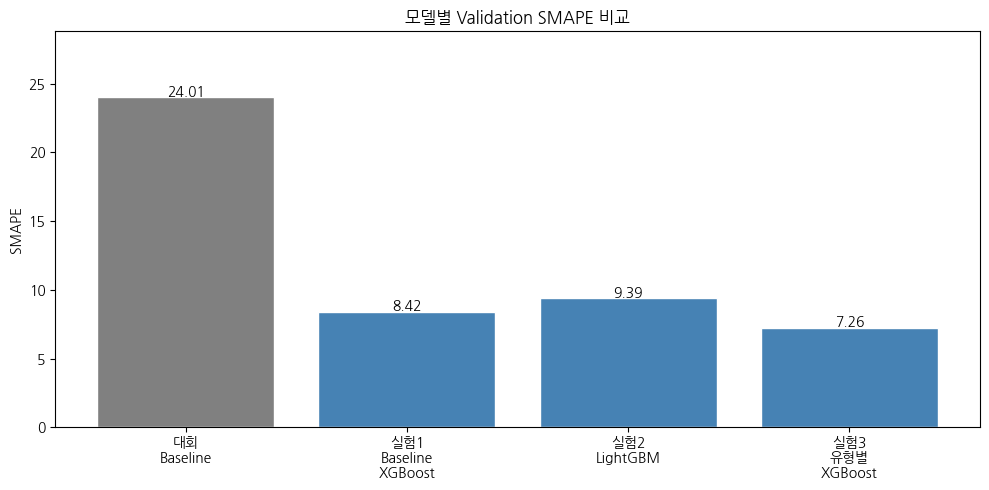

In [ ]:
print('=' * 50)
print('실험 결과 비교')
print('=' * 50)
print(f'{"실험":<30} {"SMAPE":>8} {"개선폭":>8}')
print('-' * 50)
print(f'{"대회 Baseline (원본)":<30} {"24.0140":>8} {"-":>8}')

prev = 24.0140
for name, score in results.items():
    improvement = prev - score
    print(f'{name:<30} {score:>8.4f} {improvement:>+8.4f}')
    prev = score

print('=' * 50)

# 시각화
plt.figure(figsize=(10, 5))
labels = ['대회\nBaseline'] + [k.replace('_', '\n') for k in results.keys()]
scores = [24.0140] + list(results.values())
colors = ['gray'] + ['steelblue'] * len(results)

bars = plt.bar(labels, scores, color=colors, edgecolor='white')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.title('모델별 Validation SMAPE 비교')
plt.ylabel('SMAPE')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()

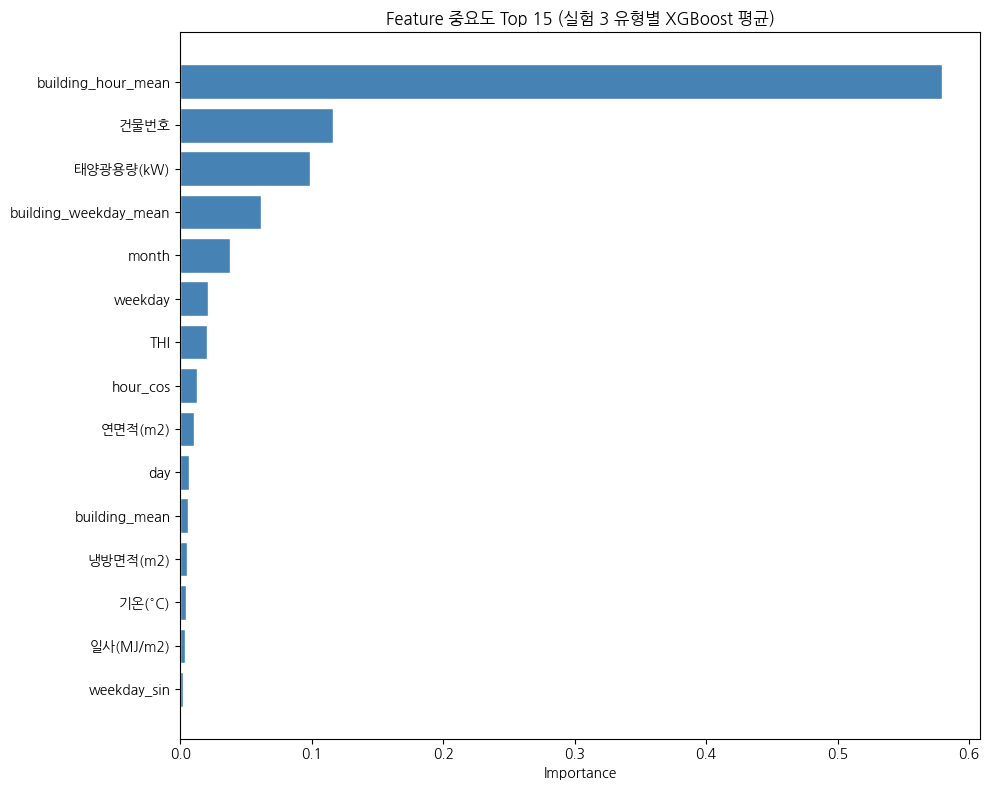

상위 5개 feature:
                  feature  importance
25     building_hour_mean    0.579428
0                    건물번호    0.116152
4               태양광용량(kW)    0.099068
26  building_weekday_mean    0.061406
10                  month    0.037730


In [ ]:
# 실험 3 유형별 모델에서 feature 중요도 합산
# 유형별로 모델이 따로 있으므로 전체 평균을 냄

importance_dict = {}

for btype, model in models_exp3.items():
    for feat, imp in zip(TRAIN_FEATURES, model.feature_importances_):
        if feat not in importance_dict:
            importance_dict[feat] = []
        importance_dict[feat].append(imp)

importance = pd.DataFrame({
    'feature':    list(importance_dict.keys()),
    'importance': [np.mean(v) for v in importance_dict.values()]
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15],
         importance['importance'][:15],
         color='steelblue', edgecolor='white')
plt.title('Feature 중요도 Top 15 (실험 3 유형별 XGBoost 평균)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('상위 5개 feature:')
print(importance.head())

In [ ]:
result_path = DATA_DIR + 'experiment_results.csv'

new_results = pd.DataFrame([
    {
        '실험번호': 0,
        '실험명': '대회_Baseline_XGBoost',
        'SMAPE': 24.0140,
        '개선폭': 0,
        '비고': '대회 제공 Baseline, Feature Engineering 없음'
    },
    {
        '실험번호': 1,
        '실험명': 'FE_XGBoost',
        'SMAPE': 8.4242,
        '개선폭': 24.0140 - 8.4242,
        '비고': 'Feature Engineering 추가 효과'
    },
    {
        '실험번호': 2,
        '실험명': 'LightGBM_전체',
        'SMAPE': 9.3881,
        '개선폭': 8.4242 - 9.3881,
        '비고': 'XGBoost보다 성능 낮음'
    },
    {
        '실험번호': 3,
        '실험명': '유형별_XGBoost',
        'SMAPE': 7.2579,
        '개선폭': 9.3881 - 7.2579,
        '비고': '유형별 모델 분리 효과 확인'
    },
])

if os.path.exists(result_path):
    existing = pd.read_csv(result_path)
    combined = pd.concat([existing, new_results], ignore_index=True)
    combined = combined.drop_duplicates(subset='실험번호', keep='last')
    combined = combined.sort_values('실험번호').reset_index(drop=True)
    combined.to_csv(result_path, index=False)
else:
    new_results.to_csv(result_path, index=False)

print('실험 결과 저장 완료')
print(pd.read_csv(result_path))

실험 결과 저장 완료
   실험번호                  실험명    SMAPE      개선폭  \
0     0  대회_Baseline_XGBoost  24.0140   0.0000   
1     1           FE_XGBoost   8.4242  15.5898   
2     2          LightGBM_전체   9.3881  -0.9639   
3     3          유형별_XGBoost   7.2579   2.1302   

                                       비고  
0  대회 제공 Baseline, Feature Engineering 없음  
1               Feature Engineering 추가 효과  
2                         XGBoost보다 성능 낮음  
3                         유형별 모델 분리 효과 확인  
